<a href="https://colab.research.google.com/github/castrokelly/PPGIa/blob/main/atividade_5_rotacao_letra_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pontifícia Universidade Católica do Paraná

**Aluna:** 40131556 - Kelly Christine Alvarenga de Castro (christine.kelly@pucpr.edu.br)  
**Mestrado / Turma:** PPGIa (404) 2026/02  
**Disciplina:** Fundamentos de Matemática Computacional (Turma ME)  
**Professor:** Dr. Vinícius Mourão Alves de Souza  

# ATIVIDADE 5 — Transformação linear: rotação da letra A

**Base:** material da Semana 5, especialmente o exercício da página 15.

## Objetivo

O exercício pede a representação da letra **A** por meio de matrizes e a aplicação de uma transformação linear de rotação em torno da origem \((0,0)\).

A rotação deve completar \(360^\circ\), atualizando a figura a cada \(10^\circ\). Para cada ângulo, será utilizada a matriz de rotação apresentada no material:

\[
M =
\begin{bmatrix}
\cos(\theta) & -\sin(\theta) \\
\sin(\theta) & \cos(\theta)
\end{bmatrix}
\]

Se os pontos da letra A estiverem armazenados em uma matriz \(A\), a figura transformada é obtida por:

\[
T = M @ A
\]


## 1. Importação das bibliotecas

Serão utilizadas apenas as bibliotecas necessárias para a atividade:

- `numpy` para representar as matrizes e calcular seno e cosseno;
- `matplotlib.pyplot` para desenhar a letra;
- `clear_output` para atualizar os frames da animação no notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

## 2. Modelagem da letra A com matrizes

A letra A será formada por dois conjuntos de pontos:

- `A1`: contorno externo da letra;
- `A2`: contorno interno da letra.

Cada matriz possui duas linhas. A primeira linha contém as coordenadas \(x\) e a segunda contém as coordenadas \(y\).

A origem \((0,0)\) foi escolhida como um dos pontos da base da letra, pois a rotação solicitada deve ocorrer em torno dessa origem.

In [2]:
# Contorno externo da letra A
A1 = np.array([
    [0.0, 1.4, 2.6, 4.0, 3.0, 2.6, 1.4, 1.0, 0.0],
    [0.0, 5.0, 5.0, 0.0, 0.0, 1.5, 1.5, 0.0, 0.0]
])

# Contorno interno da letra A
A2 = np.array([
    [1.65, 2.0, 2.35, 1.65],
    [2.2, 3.5, 2.2, 2.2]
])

print("Dimensão de A1:", A1.shape)
print("Dimensão de A2:", A2.shape)

Dimensão de A1: (2, 9)
Dimensão de A2: (2, 4)


## 3. Visualização da letra A antes da transformação

Antes de aplicar a rotação, podemos desenhar os pontos originais para verificar a forma definida pelas matrizes `A1` e `A2`.

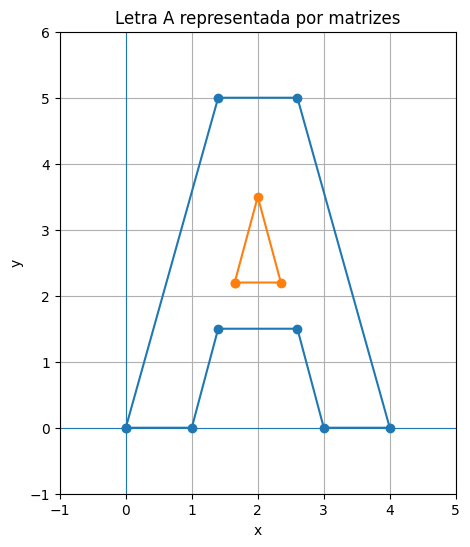

In [3]:
plt.figure(figsize=(6, 6))

plt.plot(A1[0], A1[1], marker='o')
plt.plot(A2[0], A2[1], marker='o')

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlim(-1, 5)
plt.ylim(-1, 6)
plt.gca().set_aspect('equal', adjustable='box')

plt.title("Letra A representada por matrizes")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()

plt.show()

## 4. Aplicação da matriz de rotação

O NumPy utiliza radianos nas funções trigonométricas. Por isso, um ângulo em graus é convertido com:

```python
theta = np.radians(angulo)
```

Para cada valor de \(\theta\), construímos a matriz de rotação \(M\). Em seguida, multiplicamos essa matriz pelos pontos da letra:

\[
T_1 = M @ A_1
\]

\[
T_2 = M @ A_2
\]

O exemplo abaixo aplica uma rotação de \(10^\circ\), exatamente como sugerido no slide.

In [4]:
angulo = 10
theta = np.radians(angulo)

M = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

T1 = M @ A1
T2 = M @ A2

print("Matriz de rotação para 10 graus:")
print(M)

Matriz de rotação para 10 graus:
[[ 0.98480775 -0.17364818]
 [ 0.17364818  0.98480775]]


## 5. Visualização de uma rotação de 10°

A figura abaixo mostra o resultado da primeira transformação. Os pontos da letra foram alterados pela multiplicação matricial, mas a forma da letra foi preservada.

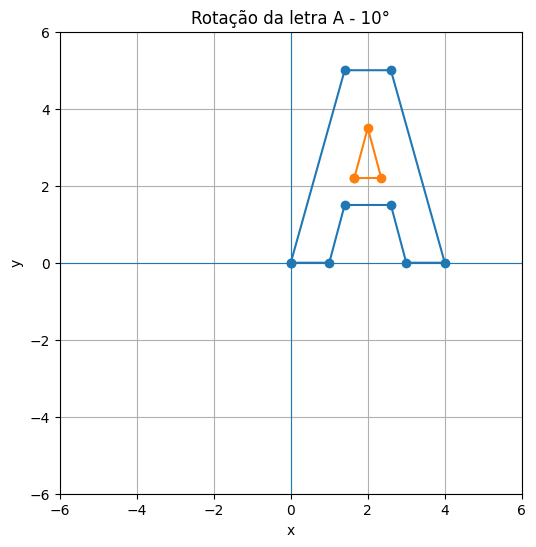

In [8]:
plt.figure(figsize=(6, 6))

plt.plot(T1[0], T1[1], marker='o')
plt.plot(T2[0], T2[1], marker='o')

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.gca().set_aspect('equal', adjustable='box')

plt.title("Rotação da letra A - 10°")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()

plt.show()

## 6. Animação da rotação completa

Agora repetimos a mesma transformação para os ângulos de \(0^\circ\) até \(360^\circ\), com incremento de \(10^\circ\).

Em cada repetição:

1. o ângulo é convertido para radianos;
2. a matriz de rotação é construída;
3. os pontos de `A1` e `A2` são transformados por multiplicação matricial;
4. o frame correspondente é desenhado;
5. `clear_output(wait=True)` substitui o frame anterior pelo novo.

O intervalo `range(0, 361, 10)` inclui o ângulo final de \(360^\circ\).

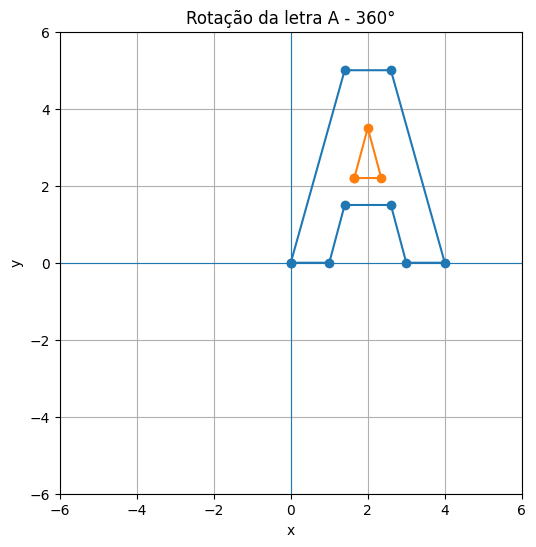

In [9]:
for angulo in range(0, 361, 10):

    # Converte o ângulo de graus para radianos
    theta = np.radians(angulo)

    # Matriz de rotação
    M = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    # Aplica a transformação linear aos dois conjuntos de pontos
    T1 = M @ A1
    T2 = M @ A2

    # Desenha o frame atual
    plt.figure(figsize=(6, 6))

    plt.plot(T1[0], T1[1], marker='o')
    plt.plot(T2[0], T2[1], marker='o')

    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)

    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.gca().set_aspect('equal', adjustable='box')

    plt.title(f"Rotação da letra A - {angulo}°")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid()

    plt.show()
    plt.pause(0.1)

    clear_output(wait=True)

## 7. Verificação da rotação de 360°

Uma rotação completa de \(360^\circ\) deve levar a letra de volta à posição inicial.

Numericamente, pequenos erros de ponto flutuante podem aparecer nas funções trigonométricas. Por isso, usamos `np.allclose` para verificar se os pontos obtidos após \(360^\circ\) são equivalentes aos pontos originais.

In [7]:
theta = np.radians(360)

M360 = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

T1_360 = M360 @ A1
T2_360 = M360 @ A2

print("A1 retorna à posição inicial:", np.allclose(T1_360, A1))
print("A2 retorna à posição inicial:", np.allclose(T2_360, A2))

A1 retorna à posição inicial: True
A2 retorna à posição inicial: True


## Conclusão

A letra A foi representada por matrizes de coordenadas e rotacionada no plano por meio de uma transformação linear.

Para cada incremento de \(10^\circ\), foi criada a matriz de rotação

\[
M =
\begin{bmatrix}
\cos(\theta) & -\sin(\theta) \\
\sin(\theta) & \cos(\theta)
\end{bmatrix}
\]

e os novos pontos foram obtidos pelas multiplicações `M @ A1` e `M @ A2`.

A animação mostra a letra completando uma volta de \(360^\circ\) em torno da origem \((0,0)\). A verificação final com `np.allclose` confirma que, após a rotação completa, os pontos retornam numericamente à posição inicial, considerando a tolerância necessária para erros de ponto flutuante.